In [7]:
import os
from nilearn.image import mean_img

bids_path = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_path = '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep/'
fmri_img = os.path.join(fmriprep_path,
                        'sub-01/func/sub-01_task-AA_acq-0500_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz')


In [18]:
mean_img = mean_img(fmri_img)

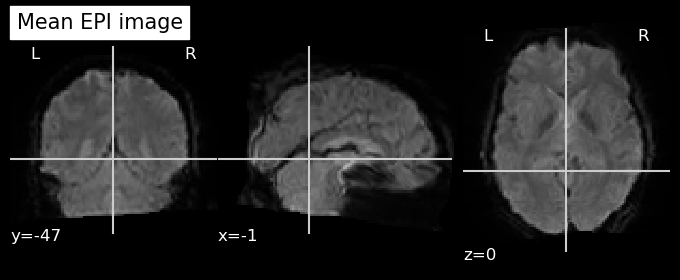

In [19]:
from nilearn.plotting import plot_anat, plot_img, plot_stat_map

plot_anat(mean_img, title='Mean EPI image')

In [8]:
import pandas as pd

events = pd.read_table(os.path.join(bids_path,
                                    'sub-01/func/sub-01_task-AA_acq-0500_run-1_events.tsv'))
events

,onset,duration,trial_type
0,0,15,Discard
1,15,30,Static
2,45,120,Ambiguous
3,165,15,MAE
4,180,30,Static
5,210,120,Ambiguous
6,330,15,MAE
7,345,30,Static
8,375,15,Discard


In [11]:
from nilearn.glm.first_level import FirstLevelModel

fmri_glm = FirstLevelModel(
    t_r=0.5,
    noise_model="ar1",
    standardize=True,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    smoothing_fwhm=4,
    n_jobs=10
)

fmri_glm = fmri_glm.fit(fmri_img, events)

design_matrix = fmri_glm.design_matrices_[0]

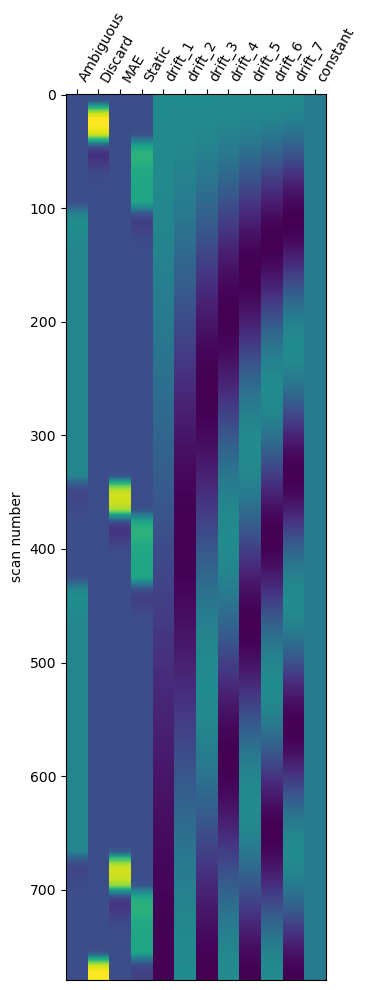

In [12]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix

plot_design_matrix(design_matrix)

plt.show()

<Axes: label='conditions'>

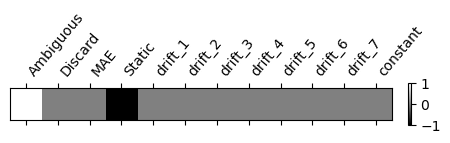

In [14]:
import numpy as np

conditions = {"Ambiguous": np.zeros(12), "Static": np.zeros(12)}
conditions["Ambiguous"][0] = 1
conditions["Static"][3] = 1

ambiguous_minus_static = conditions["Ambiguous"] - conditions["Static"]

from nilearn.plotting import plot_contrast_matrix

plot_contrast_matrix(ambiguous_minus_static, design_matrix=design_matrix, colorbar=True)

In [15]:
z_map = fmri_glm.compute_contrast(ambiguous_minus_static, output_type="z_score")

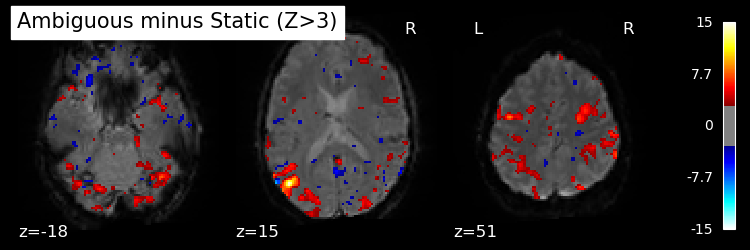

In [20]:
plot_stat_map(
    z_map,
    bg_img=mean_img,
    threshold=3.0,
    display_mode="z",
    cut_coords=3,
    black_bg=True,
    title="Ambiguous minus Static (Z>3)",
)
plt.show()

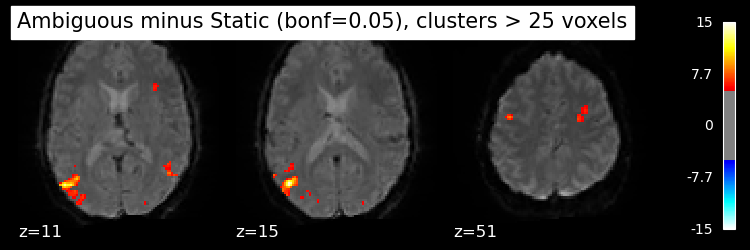

In [28]:
from nilearn.glm import threshold_stats_img

clean_map, threshold = threshold_stats_img(
    z_map, alpha=0.05, height_control="bonferroni", cluster_threshold=25
)
plot_stat_map(
    clean_map,
    bg_img=mean_img,
    threshold=threshold,
    display_mode="z",
    cut_coords=3,
    black_bg=True,
    title="Ambiguous minus Static (bonf=0.05), clusters > 25 voxels",
)
plt.show()

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



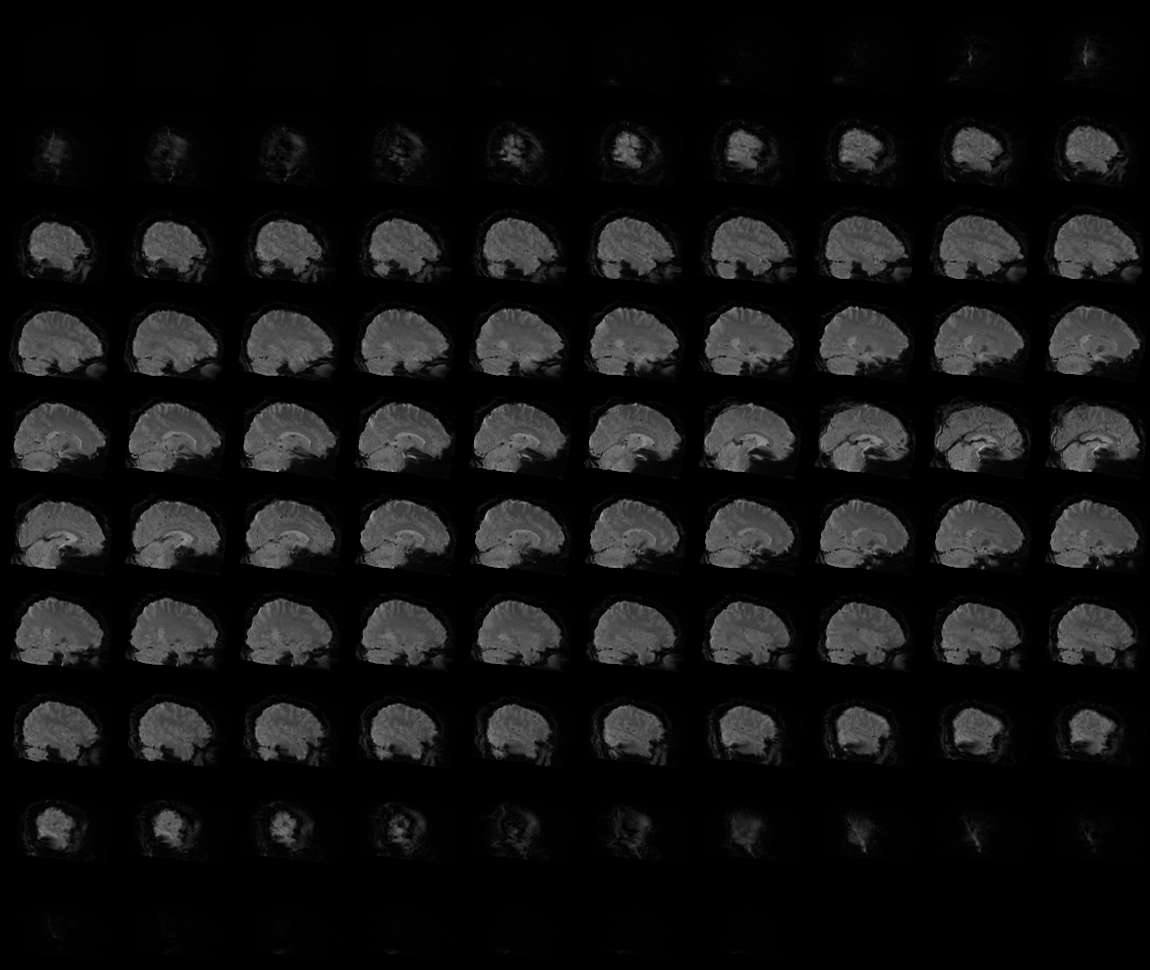
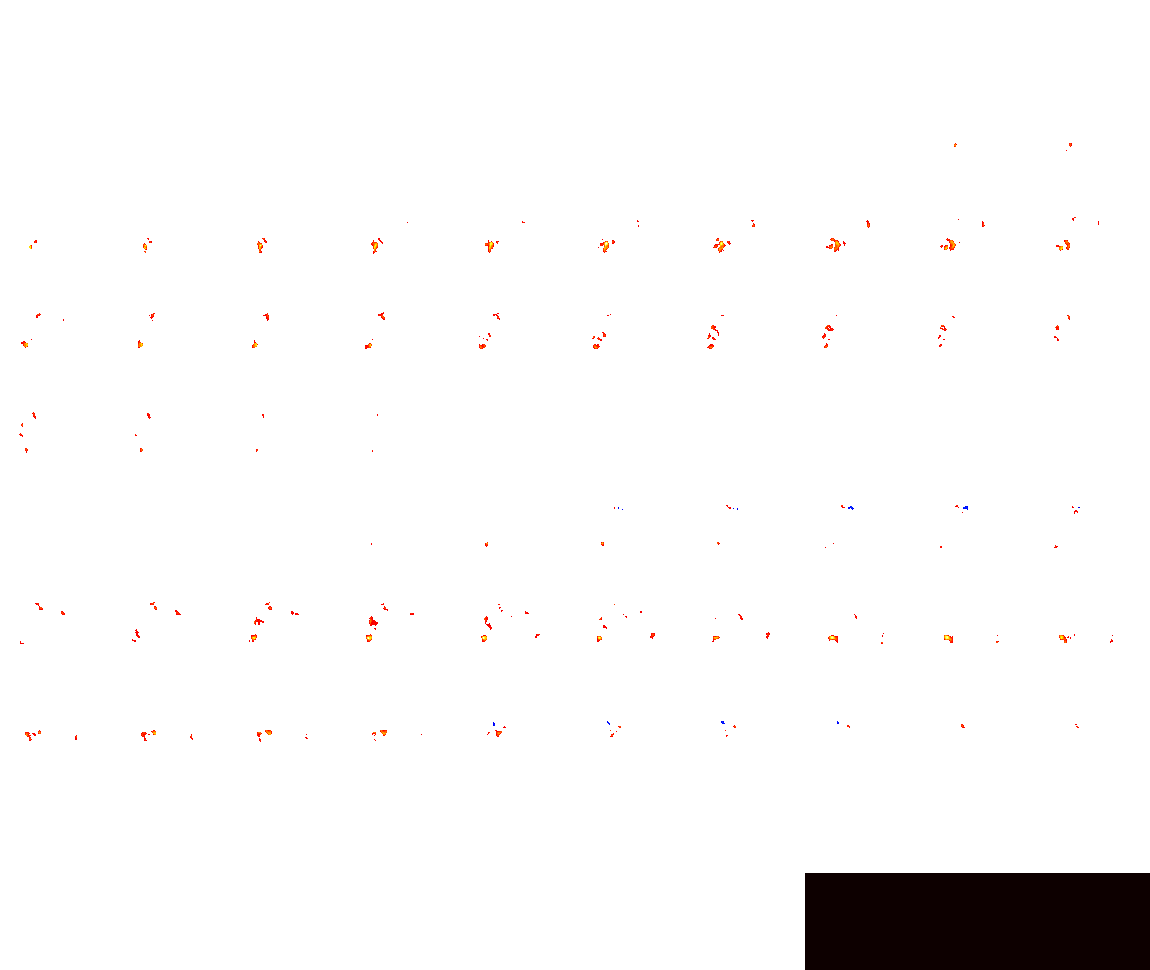

In [30]:
from nilearn.plotting import view_img

view_img(clean_map,
         bg_img=mean_img,
         threshold=threshold
        )

In [29]:
from nilearn.reporting import get_clusters_table

table = get_clusters_table(
    z_map, stat_threshold=threshold, cluster_threshold=20
)
table

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,29.5,-86.5,1.5,15.416867,3392
1,1a,37.5,-78.5,3.5,14.322291,
2,1b,47.5,-74.5,7.5,9.077820,
3,1c,41.5,-72.5,-4.5,8.367714,
4,2,-46.5,-70.5,15.5,14.959587,6136
5,2a,-56.5,-72.5,7.5,11.575213,
6,2b,-32.5,-80.5,7.5,11.555842,
7,2c,-50.5,-74.5,7.5,11.426597,
8,3,45.5,-54.5,5.5,10.467579,1024
9,3a,53.5,-58.5,1.5,7.682524,
